In [31]:

import numpy as np
from tqdm import trange
from pathlib import Path
import matplotlib.pyplot as plt
import time
import sys
import pandas as pd
import scipy
import sympy as sp
from scipy.interpolate import interp1d

import os
import sklearn.gaussian_process as gp
from scipy import stats


sys.path.append('../..')
sys.path.append('../GP_regr')
import plot_settings
import importlib
#import multi_exp_log
import SR_lib

import GP



from IPython.display import display, Math

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(plot_settings)
    importlib.reload(SR_lib)
    importlib.reload(GP)

import_reload()
GP_FIT = GP.GP_process()

# Importing data

In [32]:
RUN_ID = 'test2'
SAVE  = True
SELECTION = 'best'
DT = 1
Q0 = 17921.57581 
ITS = int(2e1)

# check if run_id exists, if not create it
if os.path.exists(f'saved_sr_models/{RUN_ID}/model_UE_{RUN_ID}.csv'):
    raise ValueError(f'Run ID {RUN_ID} already exists. Please choose a different one.')

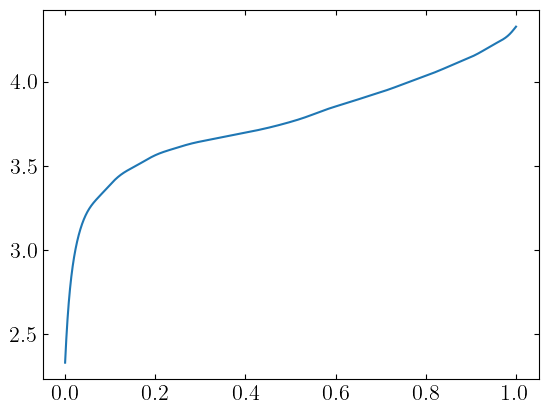

In [33]:
soc = np.linspace(0,1.0,int(1e4))
Ue = GP.soc_to_Ue(soc,GP_FIT) 
#t = np.linspace(0,3600,int(1e4))
plt.plot(soc, Ue)

In [34]:
X_train = soc.reshape(-1,1)
Y_train = Ue.reshape(-1,1)

# $U_{eq} = f_U(\mathrm{SOC})$

Variable names for element Ue: ['soc']
Running symbolic regression for element Ue with run_id Ueq_test2...
Settings: iterations=20, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.096151486
Equation: 3.7616827

Model 1: Complexity=3, Loss=0.010166911
Equation: soc + 3.26207

Model 2: Complexity=4, Loss=0.009427581
Equation: sqrt(soc) + 3.0942981

Model 3: Complexity=6, Loss=0.005063489
Equation: (sqrt(soc) * 1.2816949) - -2.908247

Model 4: Complexity=7, Loss=0.0040597287
Equation: sqrt(sqrt(soc * 12.334819)) - -2.2624958

Model 5: Complexity=9, Loss=0.0038639435
Equation: exp(sqrt(sqrt(soc ^ 0.811056))) - -1.4445546

Model 6: Complexity=10, Loss=0.0024272294
Equation: sqrt(sqrt(tan(soc) * 6.5081725)) - -2.4326494

Model 7: Complexity=13, Loss=0.0011645367
Equation: (sqrt(sqrt(tan(soc))) * 2.8473935) + (2.0602608 - sqrt(soc))

Model 8: Complexity=16, Loss=0.0009898304
Equation: ((sqrt(sqrt(tan(sqrt(soc * 1.3100955)))) * 3.6159332) + 0.8398523) - sqrt(soc)

Model 9: Complexity=20, Loss=0.00089339545
Equation: (1.629051 - sqrt(sin(soc))) + (sqrt(sqrt(tan(sqrt(soc * sqrt(soc))))) * 3.154903)

Model 10: Complexity=22, Loss=0.0008804375


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: sqrt(soc) - soc + (-soc**soc + (soc + 0.27212957)**soc + 1.35653712)**3
Loss: 0.00054813724
Best model complexity: 23


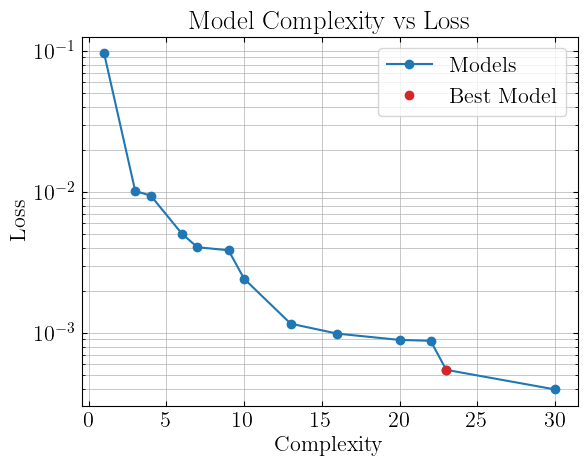

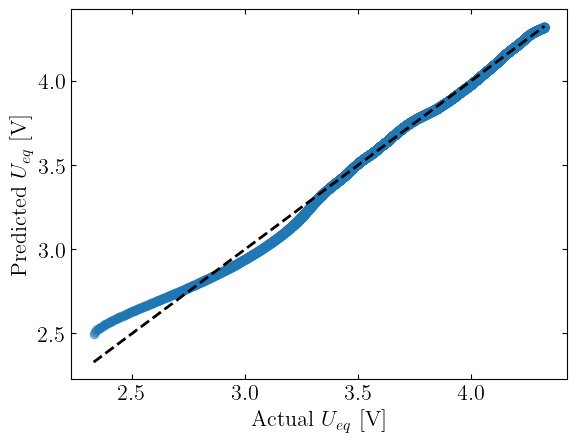

In [35]:
import_reload()
model_Ue = SR_lib.run_symbolic_regression(X_train, Y_train, model = None,run_id = f'Ueq_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'Ue')
df_model_Ue = model_Ue.equations_
SR_lib.print_models(df_model_Ue)
SR_lib.print_best_model(model_Ue)
SR_lib.pareto_plot(model_Ue)
SR_lib.parity_plot_Ue(model_Ue, Y_train, X_train, colors=colors, data_set='train')

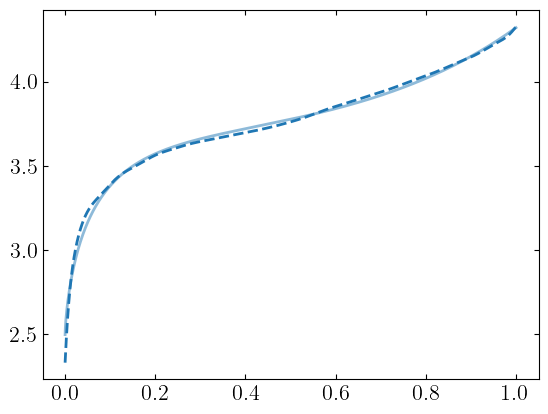

In [36]:
plt.plot(soc, model_Ue.predict(X_train), color=colors[0], alpha = 0.5, label = 'SR fit', lw = 2)
plt.plot(soc, Ue, color = colors[0],ls = '--', lw = 2, label = 'GP fit')

In [37]:
if SAVE:
    SR_lib.save_expressions(df_model_Ue,  f'Ue_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_Ue.get_best(), f'Ue_best_{RUN_ID}', run_id = RUN_ID)
    
    #save_expressions(df_model_R1, f'R1_{RUN_ID}')
    #save_expressions(df_model_C1, f'C1_{RUN_ID}')